# CS610 Assignment 1 Q5 — Twitter Bot Detection
**Task:** Binary classification — distinguish bot accounts (target=1) from genuine users (target=0).  
**Metric:** AUC (Area Under ROC Curve)

## 1. Setup & Imports

In [77]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   - -------------------------------------- 4.7/100.2 MB 25.9 MB/s eta 0:00:04
   ---- ----------------------------------- 10.5/100.2 MB 27.3 MB/s eta 0:00:04
   ------ --------------------------------- 16.5/100.2 MB 27.4 MB/s eta 0:00:04
   -------- ------------------------------- 22.0/100.2 MB 27.3 MB/s eta 0:00:03
   -------- ------------------------------- 22.0/100.2 MB 27.3 MB/s eta 0:00:03
   --------- ------------------------------ 23.1/100.2 MB 19.0 MB/s eta 0:00:05
   --------- ------------------------------ 23.1/100.2 MB 19.0 MB/s eta 0:00:05
   ---------- ----------------------------- 26.2/100.2 MB 16.4 MB/s eta 0:00:05
   ----------- ---------------------------- 28.8/100.2 MB 15.2 MB/s eta 0:00:05
   ------------ --------------------------- 30.4/100.2 MB 15.6 MB/s eta 0:00:05
   ------------ --------------------------- 31.5/100.2 MB 14.1 MB/s eta 0:00:05
   ------------- -------------------------- 33.6/1

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_curve

from catboost import CatBoostClassifier
from sklearn.metrics import r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [13]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
train.head(3)

Train shape : (26206, 19)
Test shape  : (11232, 19)


,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,target
0,2012-01-15 23:40:09,True,False,Cosplayer/Fitness lover. Come to me https://t....,74,7,0,False,465096524,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9666745212...,reml5477,20,False,0.006,3138,1
1,2016-10-04 00:44:39,False,False,pobody’s nerfect,50443,164,590,True,783105517673648132,cy,she/her,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1281752126...,kinlibra,6469,False,4.572,1415,0
2,2009-05-23 04:04:13,False,False,gracias por participar 🏅,9394,208,189,False,41970759,es,La diaspora,http://abs.twimg.com/images/themes/theme17/bg.gif,http://pbs.twimg.com/profile_images/1233811596...,_delaualau,30296,False,7.378,4106,0


## 3. Exploratory Data Analysis

In [ ]:
# --- Target distribution ---
print('Target distribution (train):')
print(train['target'].value_counts())
print(f'Bot rate: {train["target"].mean():.2%}')

8783/(8783+17423)

Target distribution (train):
target
0    17423
1     8783
Name: count, dtype: int64
Bot rate: 33.52%


0.3351522552087308

In [17]:
train.describe()

,favourites_count,followers_count,friends_count,id,statuses_count,average_tweets_per_day,account_age_days,target
count,26206.000000,2.620600e+04,2.620600e+04,2.620600e+04,2.620600e+04,26206.000000,26206.000000,26206.000000
mean,12159.971342,3.732983e+05,4.427275e+03,1.253306e+17,2.072485e+04,6.754636,3017.870831,0.335152
std,33628.948536,2.515996e+06,4.602204e+04,3.035728e+17,6.345569e+04,22.782745,1018.958572,0.472053
min,0.000000,0.000000e+00,0.000000e+00,5.860000e+02,0.000000e+00,0.000000,483.000000,0.000000
25%,347.000000,3.400000e+01,3.400000e+01,9.799366e+07,1.331000e+03,0.486250,2302.000000,0.000000
50%,2037.000000,3.540000e+02,2.920000e+02,3.997210e+08,4.143500e+03,1.464000,3218.000000,0.000000
75%,8751.750000,8.241500e+03,8.780000e+02,2.480241e+09,1.679150e+04,5.460000,3895.000000,1.000000
max,839929.000000,1.216415e+08,1.641962e+06,1.120974e+18,2.771910e+06,1191.286000,5151.000000,1.000000


In [19]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26206 entries, 0 to 26205
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   created_at                    26206 non-null  object 
 1   default_profile               26206 non-null  bool   
 2   default_profile_image         26206 non-null  bool   
 3   description                   21115 non-null  object 
 4   favourites_count              26206 non-null  int64  
 5   followers_count               26206 non-null  int64  
 6   friends_count                 26206 non-null  int64  
 7   geo_enabled                   26206 non-null  bool   
 8   id                            26206 non-null  int64  
 9   lang                          20618 non-null  object 
 10  location                      26204 non-null  object 
 11  profile_background_image_url  22971 non-null  object 
 12  profile_image_url             26205 non-null  object 
 13  s

In [16]:
# --- Missing values ---
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values (train):')
print(missing)

Columns with missing values (train):
lang                            5588
description                     5091
profile_background_image_url    3235
location                           2
profile_image_url                  1
dtype: int64


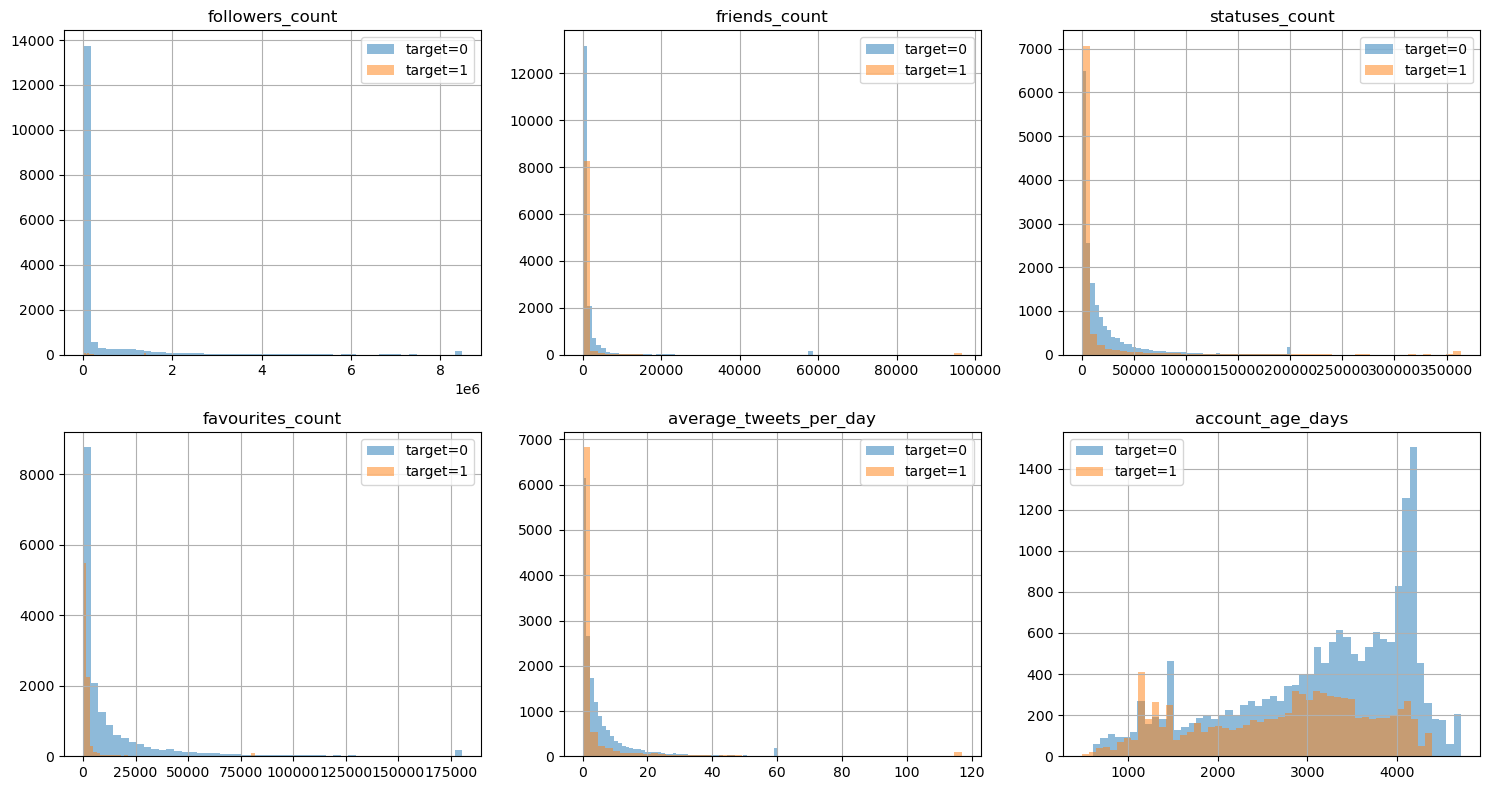

In [20]:
# --- Numeric feature distributions by class ---
numeric_cols = ['followers_count', 'friends_count', 'statuses_count',
                'favourites_count', 'average_tweets_per_day', 'account_age_days']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    for label, grp in train.groupby('target'):
        grp[col].clip(upper=grp[col].quantile(0.99)).hist(
            bins=50, ax=ax, alpha=0.5, label=f'target={label}')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# --- Boolean feature bot rates ---
bool_cols = ['default_profile', 'default_profile_image', 'geo_enabled', 'verified']
for col in bool_cols:
    rate = train.groupby(col)['target'].mean()
    print(f'{col}:\n{rate}\n')

default_profile:
default_profile
False    0.218076
True     0.496059
Name: target, dtype: float64

default_profile_image:
default_profile_image
False    0.329861
True     0.689119
Name: target, dtype: float64

geo_enabled:
geo_enabled
False    0.479769
True     0.159195
Name: target, dtype: float64

verified:
verified
False    0.409719
True     0.040951
Name: target, dtype: float64



## 4. Feature Engineering

In [71]:
def feature_engineer(df):
    df = df.copy()

    # ---- Date/time features ----
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
    df['account_hour']      = df['created_at'].dt.hour
    df['account_dayofweek'] = df['created_at'].dt.dayofweek  # ✅ put back
    df['account_year']      = df['created_at'].dt.year

    # ---- Ratio features ----
    eps = 1e-6
    df['followers_friends_ratio'] = df['followers_count'] / (df['friends_count']    + eps)
    df['friends_followers_ratio'] = df['friends_count']   / (df['followers_count']  + eps)
    df['tweet_per_follower']      = df['statuses_count']  / (df['followers_count']  + eps)
    df['favourite_per_follower']  = df['favourites_count']/ (df['followers_count']  + eps)
    df['tweet_per_age']           = df['statuses_count']  / (df['account_age_days'] + eps)
    df['favourite_per_age']       = df['favourites_count']/ (df['account_age_days'] + eps)
    df['followers_per_age']       = df['followers_count'] / (df['account_age_days'] + eps)
    df['friends_per_age']         = df['friends_count']   / (df['account_age_days'] + eps)

    # ---- Description features ----
    df['description_length']   = df['description'].fillna('').str.len()
    df['has_description']      = (df['description'].notna() & (df['description'] != '')).astype(int)
    df['description_word_cnt'] = df['description'].fillna('').str.split().str.len()
    df['has_url_in_desc']      = df['description'].fillna('').str.contains('http', case=False).astype(int)

    # ---- Screen name features ----
    df['screen_name_len']         = df['screen_name'].fillna('').str.len()
    df['screen_name_digits']      = df['screen_name'].fillna('').str.count(r'\d')
    df['screen_name_digit_ratio'] = df['screen_name_digits'] / (df['screen_name_len'] + eps)  # ✅ put back

    # ---- Location / profile flags ----
    df['has_location']             = (df['location'].notna() & (df['location'].str.lower() != 'unknown')).astype(int)
    df['has_custom_profile_image'] = (~df['profile_image_url'].isna()).astype(int)   # ✅ put back
    df['has_custom_bg_image']      = (~df['profile_background_image_url'].isna()).astype(int)  # ✅ put back

    # ---- Language ----
    top_langs = ['en','es','pt','tr','fr','ar','ja','de','it','id']
    df['lang_clean'] = df['lang'].fillna('unknown').apply(
        lambda x: x if x in top_langs else 'other')

    # ---- Boolean to int ----
    for col in ['default_profile', 'default_profile_image', 'geo_enabled', 'verified']:
        df[col] = df[col].astype(str).map({'True': 1, 'False': 0}).fillna(0).astype(int)

    return df

train_fe = feature_engineer(train)
test_fe  = feature_engineer(test)
print('Feature engineering done.')
print(f'Train columns: {train_fe.shape[1]}')
train_fe.head(5)

Feature engineering done.
Train columns: 41


,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,...,has_description,description_word_cnt,has_url_in_desc,screen_name_len,screen_name_digits,screen_name_digit_ratio,has_location,has_custom_profile_image,has_custom_bg_image,lang_clean
0,2012-01-15 23:40:09,1,0,Cosplayer/Fitness lover. Come to me https://t....,74,7,0,0,465096524,en,...,1,6,1,8,4,0.5,0,1,1,en
1,2016-10-04 00:44:39,0,0,pobody’s nerfect,50443,164,590,1,783105517673648132,cy,...,1,2,0,8,0,0.0,1,1,1,other
2,2009-05-23 04:04:13,0,0,gracias por participar 🏅,9394,208,189,0,41970759,es,...,1,4,0,10,0,0.0,1,1,1,es
3,2009-05-17 04:31:31,0,0,Stand Up Comedian/Actor from North Philadelphi...,46,66180,1090,1,40607946,en,...,1,28,0,11,0,0.0,1,1,1,en
4,2009-02-16 13:11:21,1,0,Assignment Editor at NBC10 and President of Ja...,1223,487,867,1,20983433,en,...,1,9,0,9,0,0.0,1,1,1,en


In [72]:
# ---- Encode lang_clean ----
le = LabelEncoder()
all_langs = pd.concat([train_fe['lang_clean'], test_fe['lang_clean']])
le.fit(all_langs)
train_fe['lang_encoded'] = le.transform(train_fe['lang_clean'])
test_fe['lang_encoded']  = le.transform(test_fe['lang_clean'])

# ---- Final feature list (drop non-numeric / id columns) ----
DROP_COLS = [
    'created_at', 'description', 'lang', 'lang_clean', 'location',
    'profile_background_image_url', 'profile_image_url',
    'screen_name', 'id', 'target'
]

FEATURE_COLS = [c for c in train_fe.columns if c not in DROP_COLS]

# test has an 'index' column; remove it from features
FEATURE_COLS = [c for c in FEATURE_COLS if c != 'index']

X = train_fe[FEATURE_COLS]
y = train_fe['target']

# Align test columns
test_feat_cols = [c for c in FEATURE_COLS if c in test_fe.columns]
X_test = test_fe[test_feat_cols]

print(f'Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'X shape: {X.shape}, X_test shape: {X_test.shape}')

Features used (32): ['default_profile', 'default_profile_image', 'favourites_count', 'followers_count', 'friends_count', 'geo_enabled', 'statuses_count', 'verified', 'average_tweets_per_day', 'account_age_days', 'account_hour', 'account_dayofweek', 'account_year', 'followers_friends_ratio', 'friends_followers_ratio', 'tweet_per_follower', 'favourite_per_follower', 'tweet_per_age', 'favourite_per_age', 'followers_per_age', 'friends_per_age', 'description_length', 'has_description', 'description_word_cnt', 'has_url_in_desc', 'screen_name_len', 'screen_name_digits', 'screen_name_digit_ratio', 'has_location', 'has_custom_profile_image', 'has_custom_bg_image', 'lang_encoded']
X shape: (26206, 32), X_test shape: (11232, 32)


In [82]:
X.skew().sort_values()

has_custom_profile_image   -161.882674
has_custom_bg_image          -2.289586
has_description              -1.545606
has_location                 -0.622352
account_age_days             -0.537331
screen_name_len              -0.272288
account_hour                 -0.258752
account_dayofweek             0.090633
geo_enabled                   0.196480
description_length            0.293624
default_profile               0.319360
description_word_cnt          0.499315
account_year                  0.546892
lang_encoded                  0.608882
verified                      1.482960
has_url_in_desc               2.473650
screen_name_digit_ratio       2.580744
screen_name_digits            2.729988
favourites_count              7.806007
default_profile_image         8.056896
favourite_per_age            11.446787
statuses_count               14.401150
followers_per_age            20.982216
average_tweets_per_day       21.055353
tweet_per_age                21.055354
friends_count            

## 5. Baseline Model (Logistic Regression)

In [73]:
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_scores = cross_val_score(baseline_pipe, X, y, cv=cv, scoring='roc_auc')
baseline_r2     = cross_val_score(baseline_pipe, X, y, cv=cv, scoring='r2')

print(f'Baseline Logistic Regression  CV AUC: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}')
print(f'Baseline Logistic Regression  CV R²:  {baseline_r2.mean():.4f} ± {baseline_r2.std():.4f}')

Baseline Logistic Regression  CV AUC: 0.8449 ± 0.0051
Baseline Logistic Regression  CV R²:  0.0105 ± 0.0167


## 6. Advanced Models

### 6a. LightGBM

In [74]:
lgb_params = {
    'objective':        'binary',      # classification task (bot or not)
    'metric':           'auc',         # measure performance by AUC
    'n_estimators':     1000,          # max 1000 trees to build
    'learning_rate':    0.05,          # how fast model learns (smaller = more careful)
    'num_leaves':       63,            # complexity of each tree (higher = more complex)
    'min_child_samples': 30,           # minimum data points in a leaf (prevents overfitting)
    'subsample':        0.8,           # use 80% of rows randomly per tree
    'colsample_bytree': 0.8,           # use 80% of features randomly per tree
    'reg_alpha':        0.1,           # L1 regularization (penalizes complexity)
    'reg_lambda':       0.1,           # L2 regularization (penalizes complexity)
    'random_state':     RANDOM_STATE,  # fixes randomness for reproducibility
    'n_jobs':           -1,            # use all CPU cores
    'verbose':          -1,            # suppress training logs
}

lgb_oof   = np.zeros(len(X))       # stores predictions for training data (one per row)
lgb_preds = np.zeros(len(X_test))  # stores predictions for test data

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
    # Split data into training and validation for this fold: test.csv doesnot have target so we cant test, must create val set by ourselves.
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # Train a fresh LightGBM model
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],                          # monitor val performance
        callbacks=[lgb.early_stopping(50, verbose=False),   # stop if no improvement for 50 rounds
                   lgb.log_evaluation(-1)]                  # suppress logs
    )

    # Save validation predictions (probability of being a bot)
    lgb_oof[val_idx]  = model.predict_proba(X_val)[:, 1]
    
    # Accumulate test predictions (average across all folds)
    lgb_preds        += model.predict_proba(X_test)[:, 1] / cv.n_splits

    fold_auc = roc_auc_score(y_val, lgb_oof[val_idx])
    fold_r2  = r2_score(y_val, lgb_oof[val_idx])         # R² added
    print(f'  Fold {fold+1} AUC: {fold_auc:.4f}')

lgb_cv_auc = roc_auc_score(y, lgb_oof)
lgb_cv_r2  = r2_score(y, lgb_oof)                        # overall R² added
print(f'\nLightGBM  OOF AUC: {lgb_cv_auc:.4f}')
print(f'LightGBM  OOF R²:  {lgb_cv_r2:.4f}')


  Fold 1 AUC: 0.9385
  Fold 2 AUC: 0.9461
  Fold 3 AUC: 0.9472
  Fold 4 AUC: 0.9394
  Fold 5 AUC: 0.9398

LightGBM  OOF AUC: 0.9421
LightGBM  OOF R²:  0.6177


### 6b. XGBoost

In [75]:
# ── XGBoost Parameters ──────────────────────────────────────────────────────
xgb_params = {
    'objective':         'binary:logistic', # binary classification, outputs probability
    'eval_metric':       'auc',             # measure performance by AUC during training
    'n_estimators':      1000,              # max 1000 trees to build
    'learning_rate':     0.05,              # how fast model learns (smaller = more careful)
    'max_depth':         6,                 # max depth of each tree (higher = more complex)
    'subsample':         0.8,              # use 80% of rows randomly per tree (reduces overfitting)
    'colsample_bytree':  0.8,              # use 80% of features randomly per tree (reduces overfitting)
    'reg_alpha':         0.1,              # L1 regularization (penalizes large coefficients)
    'reg_lambda':        1.0,              # L2 regularization (penalizes large coefficients)
    'random_state':      RANDOM_STATE,     # fixes randomness so results are reproducible
    'n_jobs':            -1,               # use all CPU cores for faster training
    'verbosity':         0,                # suppress all training logs
    'early_stopping_rounds': 50,           # stop training if no AUC improvement for 50 rounds
}

# ── Empty arrays to collect predictions ─────────────────────────────────────
xgb_oof   = np.zeros(len(X))      # will store out-of-fold predictions on train data. OOF = Out-Of-Fold — predictions on data the model never trained on.
xgb_preds = np.zeros(len(X_test)) # will store averaged predictions on test data

# ── 5-Fold Cross Validation Loop ─────────────────────────────────────────────
for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):

    # Split train.csv into training and validation portions for this fold
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # Create a fresh XGBoost model with the params defined above
    model = xgb.XGBClassifier(**xgb_params)

    # Train the model; eval_set lets early stopping monitor val AUC
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)], # monitor this validation set each round
        verbose=False              # suppress per-round logs
    )

    # Predict probability of being a bot (column 1 = bot, column 0 = not bot)
    xgb_oof[val_idx]  = model.predict_proba(X_val)[:, 1]   # save val predictions
    xgb_preds        += model.predict_proba(X_test)[:, 1] / cv.n_splits  # accumulate test predictions (divide by 5 to average across folds)

    # Evaluate this fold
    fold_auc = roc_auc_score(y_val, xgb_oof[val_idx])
    fold_r2  = r2_score(y_val, xgb_oof[val_idx])           # R² for this fold
    print(f'  Fold {fold+1}  AUC: {fold_auc:.4f}  |  R²: {fold_r2:.4f}')

# ── Overall OOF Performance (all 5 folds combined) ───────────────────────────
xgb_cv_auc = roc_auc_score(y, xgb_oof) # AUC across all folds
xgb_cv_r2  = r2_score(y, xgb_oof)      # R²  across all folds
print(f'\nXGBoost  OOF AUC: {xgb_cv_auc:.4f}')
print(f'XGBoost  OOF R²:  {xgb_cv_r2:.4f}')

  Fold 1  AUC: 0.9399  |  R²: 0.6126
  Fold 2  AUC: 0.9460  |  R²: 0.6330
  Fold 3  AUC: 0.9465  |  R²: 0.6308
  Fold 4  AUC: 0.9390  |  R²: 0.6140
  Fold 5  AUC: 0.9407  |  R²: 0.6050

XGBoost  OOF AUC: 0.9423
XGBoost  OOF R²:  0.6191


### 6c. CatBoost

In [79]:
cat_params = {
    'iterations':          1000,
    'learning_rate':       0.05,
    'depth':               8,
    'eval_metric':         'AUC',
    'random_seed':         RANDOM_STATE,
    'verbose':             False
}

cat_oof   = np.zeros(len(X))
cat_preds = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostClassifier(**cat_params)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )

    cat_oof[val_idx]  = model.predict_proba(X_val)[:, 1]
    cat_preds        += model.predict_proba(X_test)[:, 1] / cv.n_splits

    fold_auc = roc_auc_score(y_val, cat_oof[val_idx])
    fold_r2  = r2_score(y_val, cat_oof[val_idx])
    print(f'  Fold {fold+1}  AUC: {fold_auc:.4f}  |  R²: {fold_r2:.4f}')

cat_cv_auc = roc_auc_score(y, cat_oof)
cat_cv_r2  = r2_score(y, cat_oof)
print(f'\nCatBoost  OOF AUC: {cat_cv_auc:.4f}')
print(f'CatBoost  OOF R²:  {cat_cv_r2:.4f}')

  Fold 1  AUC: 0.9374  |  R²: 0.6068
  Fold 2  AUC: 0.9464  |  R²: 0.6359
  Fold 3  AUC: 0.9452  |  R²: 0.6255
  Fold 4  AUC: 0.9393  |  R²: 0.6158
  Fold 5  AUC: 0.9423  |  R²: 0.6123

CatBoost  OOF AUC: 0.9418
CatBoost  OOF R²:  0.6193


## 7. Ensemble (Average LGB + XGB + CatBoost)

In [80]:
# 3-model ensemble
ensemble_oof   = (lgb_oof   + xgb_oof   + cat_oof)   / 3
ensemble_preds = (lgb_preds + xgb_preds + cat_preds) / 3

ensemble_auc = roc_auc_score(y, ensemble_oof)
ensemble_r2  = r2_score(y, ensemble_oof)

print('\n--- Model Comparison ---')
print(f'{"Model":<20} {"AUC":>8} {"R²":>8}')
print('-' * 38)
print(f'{"Baseline (LogReg)":<20} {baseline_scores.mean():>8.4f} {baseline_r2.mean():>8.4f}')
print(f'{"LightGBM":<20} {lgb_cv_auc:>8.4f} {lgb_cv_r2:>8.4f}')
print(f'{"XGBoost":<20} {xgb_cv_auc:>8.4f} {xgb_cv_r2:>8.4f}')
print(f'{"CatBoost":<20} {cat_cv_auc:>8.4f} {cat_cv_r2:>8.4f}')
print(f'{"Ensemble (3 models)":<20} {ensemble_auc:>8.4f} {ensemble_r2:>8.4f}')


--- Model Comparison ---
Model                     AUC       R²
--------------------------------------
Baseline (LogReg)      0.8449   0.0105
LightGBM               0.9421   0.6177
XGBoost                0.9423   0.6191
CatBoost               0.9418   0.6193
Ensemble (3 models)    0.9435   0.6234


## 8. Feature Importance

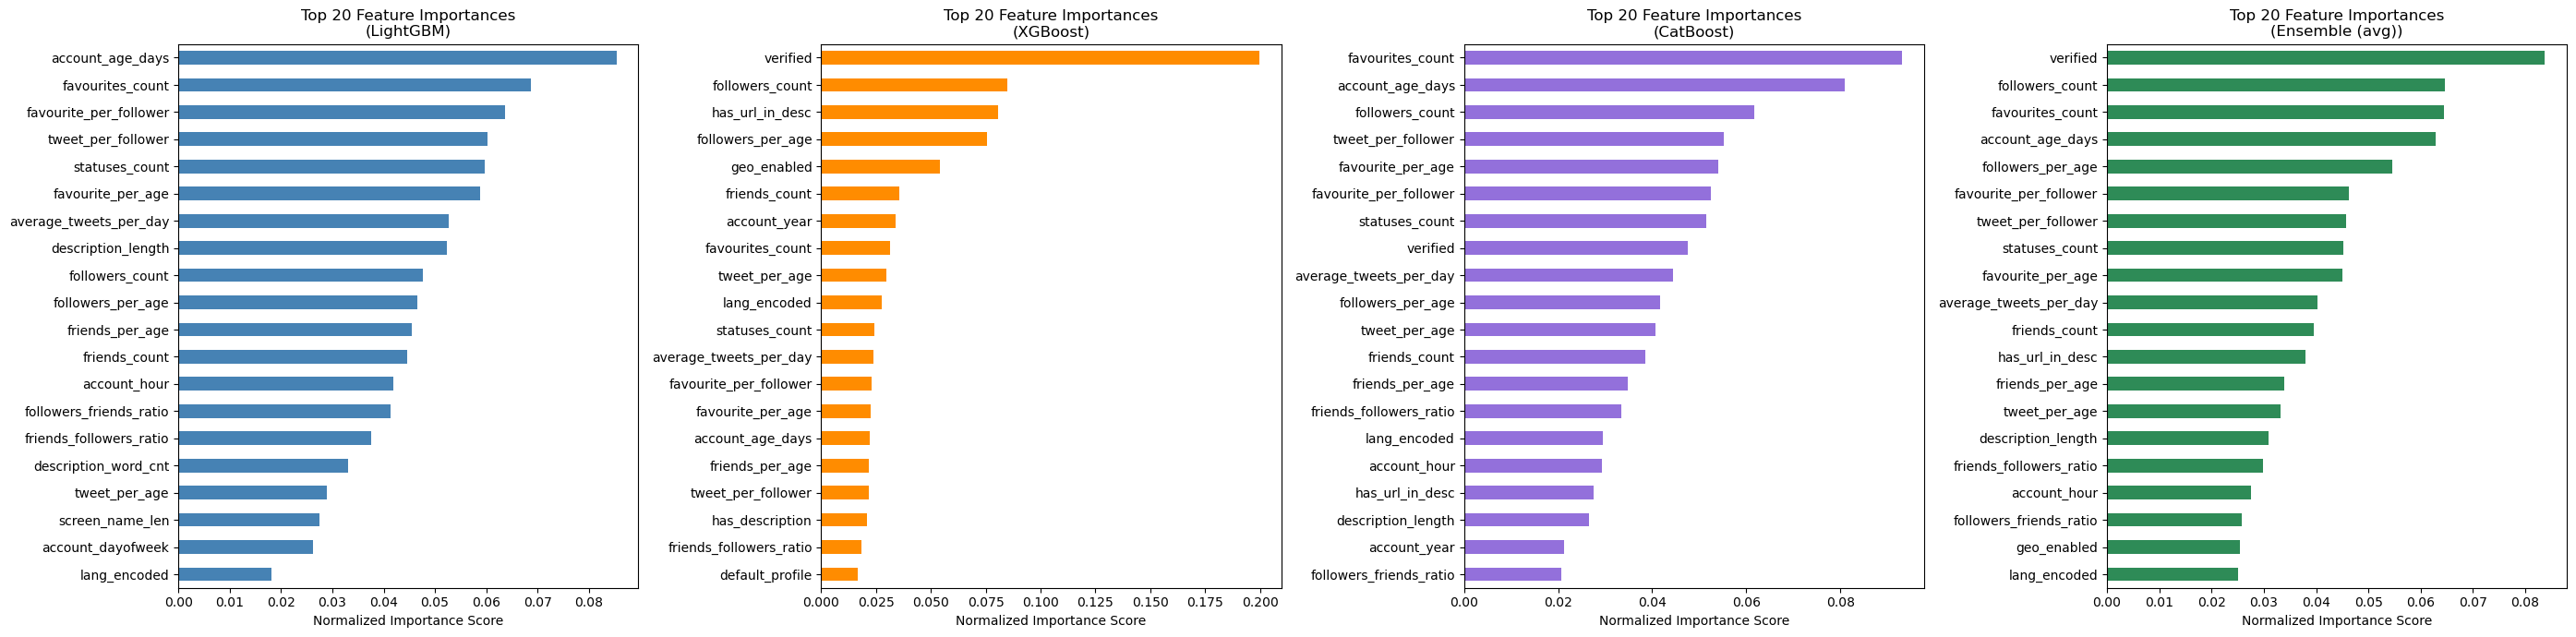

Rank   LightGBM                       XGBoost                        CatBoost                       Ensemble
-------------------------------------------------------------------------------------------------------------------
1      account_age_days               verified                       favourites_count               verified
2      favourites_count               followers_count                account_age_days               followers_count
3      favourite_per_follower         has_url_in_desc                followers_count                favourites_count
4      tweet_per_follower             followers_per_age              tweet_per_follower             account_age_days
5      statuses_count                 geo_enabled                    favourite_per_age              followers_per_age
6      favourite_per_age              friends_count                  favourite_per_follower         favourite_per_follower
7      average_tweets_per_day         account_year                   status

In [83]:
# ── Re-train LightGBM on full train set ───────────────────────────────────────
lgb_full = lgb.LGBMClassifier(**{**lgb_params, 'n_estimators': 500})
lgb_full.fit(X, y)

# ── Re-train XGBoost on full train set ───────────────────────────────────────
xgb_params_full = {k: v for k, v in xgb_params.items() if k != 'early_stopping_rounds'}
xgb_full = xgb.XGBClassifier(**xgb_params_full)
xgb_full.fit(X, y)

# ── Re-train CatBoost on full train set ──────────────────────────────────────
cat_full = CatBoostClassifier(**{**cat_params, 'iterations': 500})
cat_full.fit(X, y)

# ── Get feature importances from each model ───────────────────────────────────
lgb_imp = pd.Series(lgb_full.feature_importances_, index=FEATURE_COLS)
xgb_imp = pd.Series(xgb_full.feature_importances_, index=FEATURE_COLS)
cat_imp = pd.Series(cat_full.get_feature_importance(), index=FEATURE_COLS)

# ── Normalize each to 0-1 scale before averaging (fair comparison) ────────────
lgb_imp_norm = lgb_imp / lgb_imp.sum()
xgb_imp_norm = xgb_imp / xgb_imp.sum()
cat_imp_norm = cat_imp / cat_imp.sum()

# ── Average all three = Ensemble importance ───────────────────────────────────
ensemble_imp = (lgb_imp_norm + xgb_imp_norm + cat_imp_norm) / 3

# ── Plot all four side by side ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(28, 7))

for ax, imp, title, color in zip(
    axes,
    [lgb_imp_norm, xgb_imp_norm, cat_imp_norm, ensemble_imp],
    ['LightGBM', 'XGBoost', 'CatBoost', 'Ensemble (avg)'],
    ['steelblue', 'darkorange', 'mediumpurple', 'seagreen']
):
    top20 = imp.sort_values(ascending=False).head(20)
    top20.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Top 20 Feature Importances\n({title})', fontsize=12)
    ax.set_xlabel('Normalized Importance Score')

plt.tight_layout()
plt.show()

# ── Print top 10 comparison table ─────────────────────────────────────────────
print(f'{"Rank":<6} {"LightGBM":<30} {"XGBoost":<30} {"CatBoost":<30} {"Ensemble"}')
print('-' * 115)
lgb_top = lgb_imp_norm.sort_values(ascending=False).head(10)
xgb_top = xgb_imp_norm.sort_values(ascending=False).head(10)
cat_top = cat_imp_norm.sort_values(ascending=False).head(10)
ens_top = ensemble_imp.sort_values(ascending=False).head(10)
for i, (l, x, c, e) in enumerate(zip(lgb_top.index, xgb_top.index, cat_top.index, ens_top.index), 1):
    print(f'{i:<6} {l:<30} {x:<30} {c:<30} {e}')

## 9. ROC Curve

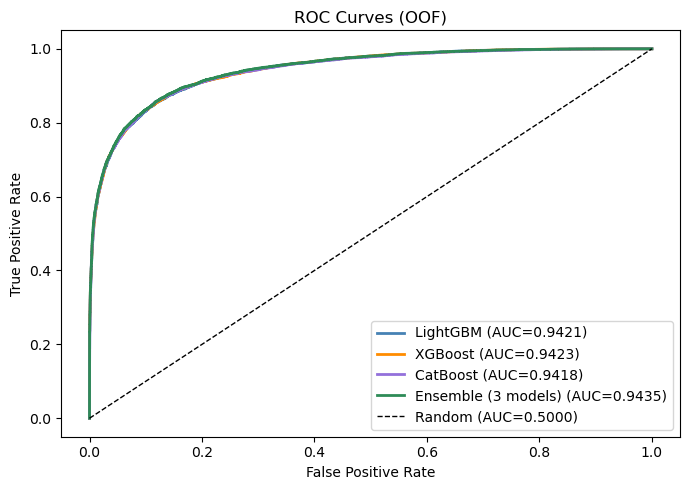

In [85]:
plt.figure(figsize=(7, 5))

for name, oof, color in [
    ('LightGBM',          lgb_oof,      'steelblue'),
    ('XGBoost',           xgb_oof,      'darkorange'),
    ('CatBoost',          cat_oof,      'mediumpurple'),
    ('Ensemble (3 models)', ensemble_oof, 'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y, oof)
    auc = roc_auc_score(y, oof)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (OOF)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Generate Submission File

In [86]:
import os
from datetime import datetime

# ── Create submission folder if it doesn't exist ─────────────────────────────
os.makedirs('submission', exist_ok=True)  # won't crash if folder already exists

# ── Get today's date ──────────────────────────────────────────────────────────
today = datetime.today().strftime('%Y%m%d')  # e.g. 20260509

# ── Auto-increment version based on existing files in submission folder ───────
version = 2
while os.path.exists(f'submission/{today}_submission_v{version}.csv'):
    version += 1  # keep incrementing until filename doesn't exist yet

filename = f'submission/{today}_submission_v{version}.csv'  # e.g. submission/20260509_submission_v1.csv

# ── Create and save submission ────────────────────────────────────────────────
submission = pd.DataFrame({
    'index':  test_fe['index'],
    'target': ensemble_preds
})

submission.to_csv(filename, index=False)
print(f'Submission saved to {filename}')
submission.head(10)

Submission saved to submission/20260509_submission_v2.csv


,index,target
0,0,0.015597
1,1,0.869649
2,2,0.036126
3,3,0.036047
4,4,0.991643
5,5,0.003432
6,6,0.959972
7,7,0.166809
8,8,0.038472
9,9,0.934955
